11493376/11490434 [==============================] - 0s 0us/step
x_train (60000, 28, 28, 1)
x_test (10000, 28, 28, 1)
y_train tf.Tensor([[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]], shape=(1, 10), dtype=float64) (60000, 1, 10)
y_test tf.Tensor([[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]], shape=(1, 10), dtype=float64) (10000, 1, 10)
Epoch 1, Loss: 2.3061537865061283, Accuracy: 10.731666666666667, Test Loss: 2.3025488591053622, Test Accuracy: 11.44
Epoch 2, Loss: 2.30275340377011, Accuracy: 11.626666666666667, Test Loss: 2.2983670388683586, Test Accuracy: 12.61
Epoch 3, Loss: 2.2973852833858195, Accuracy: 12.956666666666667, Test Loss: 2.2919030840505488, Test Accuracy: 14.483333333333334
Epoch 4, Loss: 2.2861817966302227, Accuracy: 14.955833333333333, Test Loss: 2.2751567302118674, Test Accuracy: 16.945
Epoch 5, Loss: 2.268199385558402, Accuracy: 17.404, Test Loss: 2.2560864465033403, Test Accuracy: 19.37
Epoch 6, Loss: 2.247748310454426, Accuracy: 19.864166666666666, Test Loss: 2.235125649493021, Test Accu

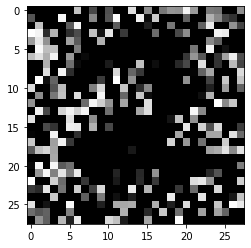

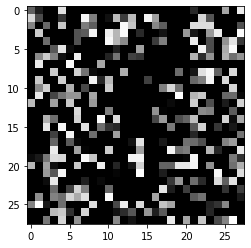

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float64')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# x_train, x_val, y_train, y_val       = train_test_split(x_train, y_train, test_size=1/12, random_state=1)

x_train                              = x_train.reshape(x_train.shape[0], 28, 28, 1)
# x_val                                = x_val.reshape(x_val.shape[0], 28, 28, 1)
x_test                               = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train                              = x_train.astype('float64')
# x_val                                = x_val.astype('float64')
x_test                               = x_test.astype('float64')

x_train /= 255
# x_val   /= 255
x_test  /= 255
############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  var             = 3
  sigma           = var**0.5
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  gauss           = np.absolute(gauss)
  return image + gauss

x_train           = Noisy(x_train)
# x_val             = Noisy(x_val)
x_test            = Noisy(x_test)

x_train = np.clip(x_train, 0, 1)
# x_val   = np.clip(x_val, 0, 1)
x_test  = np.clip(x_test, 0, 1)

# Showing an example of noisy images
print('x_train', x_train.shape)
plt.figure()
plt.imshow(x_train[4777].reshape(28,28), cmap='Greys')

# print('x_val', x_val.shape)
# plt.figure()
# plt.imshow(x_val[4777].reshape(28,28), cmap='Greys')

print('x_test', x_test.shape)
plt.figure()
plt.imshow(x_test[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim_01     = 2 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
latent_dim_02     = 5
no_sampling       = 1 # Number of sampling in latent space (it usually equals to 1)
batch_size        = 32
no_epochs         = 10
verbosity         = 1
beta_01           = 1 # Lagrange Multiplier in Loss Function
beta_02           = 1
# rate              = 0
# relevance         = 0
# T                 = 2 # Number of Stages
# validation_split  = 0.2
# input_shape       = (28, 28, 1)
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
# y_val             = one_hot_encode(y_val)
y_test            = one_hot_encode(y_test)
########################  Tiling M Same Label on Eachother ######################################
y_train           = tf.reshape(y_train, (-1, 1, 10))
y_train           = tf.tile(y_train, [1, no_sampling, 1])
# y_val             = tf.reshape(y_val, (-1, 1, 10))
# y_val             = tf.tile(y_val, [1, no_sampling, 1])
y_test             = tf.reshape(y_test, (-1, 1, 10))
y_test             = tf.tile(y_test, [1, no_sampling, 1])
print('y_train', y_train[4777], y_train.shape)
# print('y_val', y_val[4777], y_val.shape)
print('y_test', y_test[4777], y_test.shape)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).shuffle(x_test.shape[0]).batch(batch_size)
# val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).shuffle(x_val.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_ds.element_spec)
# print(val_ds.element_spec)
########################  Input Shape for Training ######################################
img_width, img_height, num_channels     = x_train.shape[1], x_train.shape[2], x_train.shape[3]
input_shape                             = (img_height, img_width, num_channels)  ## (28,28,1)

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self, latent_dim):
        super(Encoder, self).__init__()
        self.latent_dim = latent_dim
        self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
        self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
        self.flatten      = Flatten()
        self.dense_10     = Dense(1024, activation='relu')
        self.dropout      = Dropout(0.4)
        self.lineardense  = Dense(2*latent_dim, name='latent_mu')

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
        conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
        maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
        flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout1_enc_s1   = self.dropout(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout1_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(100, activation='relu')
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        dense2_dec_s1     = self.dense_02(dense1_dec_s1)
        return dense2_dec_s1

# # =================================================================================================================
# # VAE
# # =================================================================================================================
class VAE_01 (tf.keras.Model):
    def __init__(self):
        super(VAE_01, self).__init__()
        self.encoder = Encoder(latent_dim_01)
        self.decoder = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        mu_1         = tf.reshape(mu, [-1, 1, latent_dim])
        logvar_1     = tf.reshape(logvar, [-1, 1, latent_dim])
        eps          = tf.random.normal([mu_1.shape[0], no_sampling, latent_dim], 0.0, 1.0, tf.float64)
        return       mu_1 + tf.math.exp(logvar_1 / 2) * eps

    def call(self, input_vae):
        mu, logvar   = self.encoder(input_vae)
        latent_space = self.sampling(mu, logvar, latent_dim_01)     # (batch_size, no_sampling, latent_dim)
        predictions  = self.decoder(latent_space)
        return mu, logvar, predictions, latent_space

# # =================================================================================================================
# # LOSS
# # =================================================================================================================

def Loss_01(mu, logvar, labels, predictions):  # prediction size:(batch, no_sampling, 10)

    cross_ent  = tf.nn.softmax_cross_entropy_with_logits(logits=predictions, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u    = tf.math.reduce_mean(cross_ent)
    KL_loss    = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL       = (-1/2) * tf.math.reduce_mean(KL_loss)
    return D_KL + beta_01 * logqx_u



train_loss_01 = tf.keras.metrics.Mean(name='train_loss_01')
train_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_01')

test_loss_01 = tf.keras.metrics.Mean(name='test_loss_01')
test_accuracy_01 = tf.keras.metrics.CategoricalAccuracy(name='test_accuracy_01')


@tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions, latent_space = model(images)
        loss = Loss_01(mu, logvar, labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss_01(loss)
    train_accuracy_01(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions), axis=1)) #Predictions&Labels size:(batch,no_sampling,10)

@tf.function
def test_step(model, images, labels):
    mu, logvar, predictions, latent_space = model(images)
    t_loss = Loss_01(mu, logvar, labels, predictions)
    test_loss_01(t_loss)
    test_accuracy_01(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions), axis=1))

######################################### Defining Optimizer #################################################
##############################################################################################################
optimizer = tf.optimizers.Adam(learning_rate=1e-4)
##############################################################################################################
##############################################################################################################
# Create an instance of the model
model_01 = VAE_01()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_01, optimizer, images, labels)
        for test_images, test_labels in test_ds:
                test_step(model_01, test_images, test_labels)
        template = 'Epoch {}, Loss: {}, Accuracy: {}, Test Loss: {}, Test Accuracy: {}'
        print(template.format(epoch+1, train_loss_01.result(),
                              train_accuracy_01.result()*100,
                              test_loss_01.result(),
                              test_accuracy_01.result()*100))
        if epoch == 0:
          Test_Accuracy_01 = np.array([test_accuracy_01.result()*100])
        else:
          Test_Accuracy_01 = np.concatenate((Test_Accuracy_01, np.array([test_accuracy_01.result()*100])), axis=0)
##############################################################################################################################################
###############################################################################################################################################
print('##########################################################################################################################################')
###############################################################################################################################################
###############################################################################################################################################

class VAE_02 (tf.keras.Model):
    def __init__(self):
        super(VAE_02, self).__init__()
        self.encoder = Encoder(latent_dim_02)
        self.decoder = Decoder()

    def sampling (self, mu, logvar, latent_dim):
        mu_1         = tf.reshape(mu, [-1, 1, latent_dim])
        logvar_1     = tf.reshape(logvar, [-1, 1, latent_dim])
        eps          = tf.random.normal([mu_1.shape[0], no_sampling, latent_dim], 0.0, 1.0, tf.float64)
        return       mu_1 + tf.math.exp(logvar_1 / 2) * eps

    def call(self, input_vae):
        mu, logvar   = self.encoder(input_vae)
        latent_space = self.sampling(mu, logvar, latent_dim_02)
        _, _, _, model_01_latent = model_01(input_vae)  # (batch_size, no_sampling, latent_dim)
        predictions  = self.decoder(tf.reshape(tf.concat([latent_space, model_01_latent], axis = 2),[latent_space.shape[0], no_sampling, latent_dim_01+latent_dim_02]))
        # predictions  = self.decoder(latent_space)
        return mu, logvar, predictions, latent_space


def Loss_02(mu, logvar, labels, predictions_01, predictions_02):  # prediction size:(batch, no_sampling, 10)
    # print(predictions.shape)
    cross_ent_01 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_01, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_01   = tf.math.reduce_mean(cross_ent_01)
    cross_ent_02 = tf.nn.softmax_cross_entropy_with_logits(logits=predictions_02, labels=labels) #cross_ent size:(batch, no_sampling)
    logqx_u_02   = tf.math.reduce_mean(cross_ent_02)
    KL_loss      = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL         = (-1/2) * tf.math.reduce_mean(KL_loss)
    return D_KL + beta_01 * logqx_u_01 + beta_02 * logqx_u_02



train_loss_02 = tf.keras.metrics.Mean(name='train_loss_02')
train_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy_02')

test_loss_02 = tf.keras.metrics.Mean(name='test_loss_02')
test_accuracy_02 = tf.keras.metrics.CategoricalAccuracy(name='test_accuracy_02')


@tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions_02, latent_space = model(images)
        _, _, predictions_01, _ = model_01(images)
        loss = Loss_02(mu, logvar, labels, predictions_01, predictions_02)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss_02(loss)
    train_accuracy_02(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions_02), axis=1))#Predictions&Labels size:(batch,no_sampling,10)

@tf.function
def test_step(model, images, labels):
    mu, logvar, predictions_02, latent_space = model(images)
    _, _, predictions_01, _ = model_01(images)
    t_loss = Loss_02(mu, logvar, labels, predictions_01, predictions_02)
    test_loss_02(t_loss)
    test_accuracy_02(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions_02), axis=1))




model_02 = VAE_02 ()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model_02, optimizer, images, labels)
        for test_images, test_labels in test_ds:
                test_step(model_02, test_images, test_labels)
        template = 'Epoch {}, Loss: {}, Accuracy: {}, Test Loss: {}, Test Accuracy: {}'
        print(template.format(epoch+1, train_loss_02.result(),
                              train_accuracy_02.result()*100,
                              test_loss_02.result(),
                              test_accuracy_02.result()*100))
        if epoch == 0:
          Test_Accuracy_02 = np.array([test_accuracy_02.result()*100])
        else:
          Test_Accuracy_02 = np.concatenate((Test_Accuracy_02, np.array([test_accuracy_02.result()*100])), axis=0)






x_train (60000, 28, 28, 1)
x_test (10000, 28, 28, 1)
y_train tf.Tensor([[0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]], shape=(1, 10), dtype=float64) (60000, 1, 10)
y_test tf.Tensor([[0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]], shape=(1, 10), dtype=float64) (10000, 1, 10)
Epoch 1, Loss: 2.229280922493314, Accuracy: 22.858333333333334, Test Loss: 2.028707784291936, Test Accuracy: 39.300000000000004
Epoch 2, Loss: 2.025967006967698, Accuracy: 36.8925, Test Loss: 1.8226180480428935, Test Accuracy: 49.91
Epoch 3, Loss: 1.8497033465842931, Accuracy: 46.44333333333333, Test Loss: 1.6738484957940492, Test Accuracy: 56.66
Epoch 4, Loss: 1.7172613666096785, Accuracy: 52.85375, Test Loss: 1.5680988451057751, Test Accuracy: 61.1175
Epoch 5, Loss: 1.6150665359179457, Accuracy: 57.437000000000005, Test Loss: 1.4910929747792259, Test Accuracy: 64.022
Epoch 6, Loss: 1.5359608460046004, Accuracy: 60.85, Test Loss: 1.430943064699012, Test Accuracy: 66.58666666666667
Epoch 7, Loss: 1.471689969768598, Accuracy: 63.56071428571428

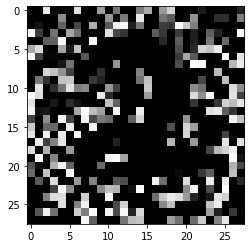

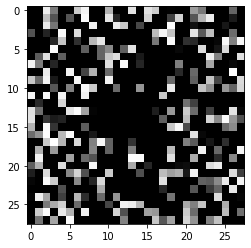

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, Input, Flatten, Dense, Lambda, Reshape, MaxPool2D, Dropout
from tensorflow.keras.models import Model
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

tf.keras.backend.set_floatx('float64')

# # ==========================================================================
# # IMPORTING and PROCESSING DATA
# # ==========================================================================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# x_train, x_val, y_train, y_val       = train_test_split(x_train, y_train, test_size=1/12, random_state=1)

x_train                              = x_train.reshape(x_train.shape[0], 28, 28, 1)
# x_val                                = x_val.reshape(x_val.shape[0], 28, 28, 1)
x_test                               = x_test.reshape(x_test.shape[0], 28, 28, 1)

x_train                              = x_train.astype('float64')
# x_val                                = x_val.astype('float64')
x_test                               = x_test.astype('float64')

x_train /= 255
# x_val   /= 255
x_test  /= 255
############  Adding Noise to data and then clipping it between [0,1] ########
def Noisy(image):
  num,row,col,ch  = image.shape
  mean            = 0
  var             = 3
  sigma           = var**0.5
  gauss           = np.random.normal(mean,sigma,(num,row,col,ch))
  gauss           = gauss.reshape(num,row,col,ch)
  gauss           = np.absolute(gauss)
  return image + gauss

x_train           = Noisy(x_train)
# x_val             = Noisy(x_val)
x_test            = Noisy(x_test)

x_train = np.clip(x_train, 0, 1)
# x_val   = np.clip(x_val, 0, 1)
x_test  = np.clip(x_test, 0, 1)

# Showing an example of noisy images
print('x_train', x_train.shape)
plt.figure()
plt.imshow(x_train[4777].reshape(28,28), cmap='Greys')

# print('x_val', x_val.shape)
# plt.figure()
# plt.imshow(x_val[4777].reshape(28,28), cmap='Greys')

print('x_test', x_test.shape)
plt.figure()
plt.imshow(x_test[4777].reshape(28,28), cmap='Greys')

# # =================================================================================================================
# # PREPROCESSING
# # =================================================================================================================
########################  DEFINING GLOBAL VARIABLES ###########################
latent_dim        = 10 # U_t assumed to be multivariate Gaussian with dimension K and diagonal covariance matrix (U is latent variable)
M                 = 1 # Number of sampling in latent space (it usually equals to 1)
batch_size        = 32
no_epochs         = 10
verbosity         = 1
beta              = 1 # Lagrange Multiplier in Loss Function
# rate              = 0
# relevance         = 0
# T                 = 2 # Number of Stages
# validation_split  = 0.2
# input_shape       = (28, 28, 1)
########################  ONE HOT ENCODING #####################################
def one_hot_encode(vec, vals=10):
    n = len(vec)
    out = np.zeros((n, vals))
    out[range(n), vec] = 1
    return out
y_train           = one_hot_encode(y_train)
# y_val             = one_hot_encode(y_val)
y_test            = one_hot_encode(y_test)
########################  Tiling M Same Label on Eachother ######################################
y_train           = tf.reshape(y_train, (-1, 1, 10))
y_train           = tf.tile(y_train, [1, M, 1])
# y_val             = tf.reshape(y_val, (-1, 1, 10))
# y_val             = tf.tile(y_val, [1, M, 1])
y_test             = tf.reshape(y_test, (-1, 1, 10))
y_test             = tf.tile(y_test, [1, M, 1])
print('y_train', y_train[4777], y_train.shape)
# print('y_val', y_val[4777], y_val.shape)
print('y_test', y_test[4777], y_test.shape)
########################  MAKING DATASET FOR CREATING BATCHES ######################################
train_ds = tf.data.Dataset.from_tensor_slices((x_train,y_train)).shuffle(x_train.shape[0]).batch(batch_size)
test_ds = tf.data.Dataset.from_tensor_slices((x_test,y_test)).shuffle(x_test.shape[0]).batch(batch_size)
# val_ds = tf.data.Dataset.from_tensor_slices((x_val,y_val)).shuffle(x_val.shape[0]).batch(batch_size)
# print(train_ds.element_spec)
# print(test_ds.element_spec)
# print(val_ds.element_spec)
########################  Input Shape for Training ######################################
img_width, img_height, num_channels     = x_train.shape[1], x_train.shape[2], x_train.shape[3]
input_shape                             = (img_height, img_width, num_channels)  ## (28,28,1)

# # =================================================================================================================
# # ENCODER
# # =================================================================================================================
class Encoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Encoder, self).__init__()
        self.conv_01      = Conv2D(filters=32, kernel_size=5, strides=1, padding='same', activation='relu')
        self.maxpool      = MaxPool2D(pool_size=(2, 2), strides=(2, 2), padding='valid')
        self.conv_02      = Conv2D(filters=64, kernel_size=5, strides=1, padding='same', activation='relu')
        self.flatten      = Flatten()
        self.dense_10     = Dense(1024, activation='relu')
        self.dropout      = Dropout(0.4)
        self.lineardense  = Dense(2*latent_dim, name='latent_mu')

    def call(self, input1_enc_s1):
        conv1_enc_s1      = self.conv_01(input1_enc_s1)
        maxpool1_enc_s1   = self.maxpool(conv1_enc_s1)
        conv2_enc_s1      = self.conv_02(maxpool1_enc_s1)
        maxpool2_enc_s1   = self.maxpool(conv2_enc_s1)
        flatten1_enc_s1   = self.flatten(maxpool2_enc_s1)
        dense1_enc_s1     = self.dense_10(flatten1_enc_s1)
        dropout1_enc_s1   = self.dropout(dense1_enc_s1)
        mu_logvar         = self.lineardense(dropout1_enc_s1)
        return tf.split(mu_logvar, num_or_size_splits=2, axis=1)

# # =================================================================================================================
# # DECODER
# # =================================================================================================================
class Decoder(tf.keras.layers.Layer):
    def __init__(self):
        super(Decoder, self).__init__()
        self.dense_01     = Dense(100, activation='relu')
        self.dense_02     = Dense(10)   # Softmax is added in Loss Function

    def call(self, input1_dec_s1):
        dense1_dec_s1     = self.dense_01(input1_dec_s1)
        dense2_dec_s1     = self.dense_02(dense1_dec_s1)
        return dense2_dec_s1

# # =================================================================================================================
# # VAE
# # =================================================================================================================
class VAE (tf.keras.Model):
    def __init__(self):
        super(VAE, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def sampling (self, mu, logvar):
        mu_1         = tf.reshape(mu, [-1, 1, latent_dim])
        logvar_1     = tf.reshape(logvar, [-1, 1, latent_dim])
        eps          = tf.random.normal([mu_1.shape[0], M, latent_dim], 0.0, 1.0, tf.float64)
        return       mu_1 + tf.math.exp(logvar_1 / 2) * eps

    def call(self, input_vae):
        mu, logvar = self.encoder(input_vae)
        predictions = self.decoder(self.sampling(mu, logvar))
        return mu, logvar, predictions

# # =================================================================================================================
# # LOSS
# # =================================================================================================================

def Loss(mu, logvar, labels, predictions):  # prediction size:(batch, M, 10)

    cross_ent  = tf.nn.softmax_cross_entropy_with_logits(logits=predictions, labels=labels) #cross_ent size:(batch, M)
    logqx_u    = tf.math.reduce_mean(cross_ent)
    KL_loss    = 1 + logvar - tf.math.square(mu) - tf.math.exp(logvar)  # mu, logvar sizes:(batch, latent_dim)
    D_KL       = (-1/2) * tf.math.reduce_mean(KL_loss)
    # global rate
    # global relevance
    # rate       += D_KL
    # relevance  += logqx_u
    # Total_loss = D_KL - beta * logqx_u
    # Total_loss =   D_KL - beta * logqx_u

    # print('labels',labels.shape)
    # print('predictions',predictions.shape)
    # print('cross_ent',cross_ent.shape)
    # print('logqx_u',logqx_u.shape)
    # print('KL_loss',KL_loss.shape)
    # print('D_KL',D_KL.shape)
          # qqq=0
    return D_KL + logqx_u



train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.CategoricalAccuracy(name='train_accuracy')

test_loss = tf.keras.metrics.Mean(name='test_loss')
test_accuracy = tf.keras.metrics.CategoricalAccuracy(name='test_accuracy')


@tf.function
def train_step(model, optimizer, images, labels):
    with tf.GradientTape() as tape:
        mu, logvar, predictions = model(images)
        loss = Loss(mu, logvar, labels, predictions)
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    train_loss(loss)
    train_accuracy(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions), axis=1)) # Predictions & Labels size:(batch,M,10)

@tf.function
def test_step(model, images, labels):
    mu, logvar, predictions = model(images)
    t_loss = Loss(mu, logvar, labels, predictions)
    test_loss(t_loss)
    test_accuracy(tf.math.reduce_mean(labels, axis=1), tf.math.reduce_mean(tf.nn.softmax(predictions), axis=1))


optimizer = tf.optimizers.Adam(learning_rate=1e-4)




# Create an instance of the model
model = VAE()
for epoch in range(no_epochs):
        for images, labels in train_ds:
                train_step(model, optimizer, images, labels)
        for test_images, test_labels in test_ds:
                test_step(model, test_images, test_labels)
        template = 'Epoch {}, Loss: {}, Accuracy: {}, Test Loss: {}, Test Accuracy: {}'
        print(template.format(epoch+1, train_loss.result(),
                              train_accuracy.result()*100,
                              test_loss.result(),
                              test_accuracy.result()*100))
        if epoch == 0:
          Test_Accuracy_10dim = np.array([test_accuracy.result()*100])
        else:
          Test_Accuracy_10dim = np.concatenate((Test_Accuracy_10dim, np.array([test_accuracy.result()*100])), axis=0)

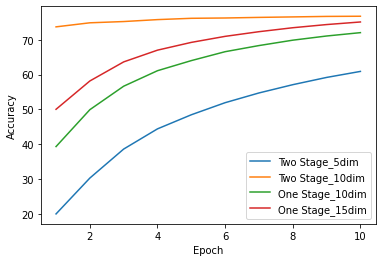

In [ ]:
plt.plot(np.arange(10)+1, Test_Accuracy_01, label='Two Stage_5dim')
plt.plot(np.arange(10)+1, Test_Accuracy_02, label='Two Stage_10dim')
plt.plot(np.arange(10)+1, Test_Accuracy_10dim, label='One Stage_10dim')
plt.plot(np.arange(10)+1, Test_Accuracy_15dim, label='One Stage_15dim')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()